In [4]:
import torch
import torchvision
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, ToTensor
from ViT_CX.ViT_CX import ViT_CX
from model.explainability import explain_VIT_CX as explain_VIT_CX
import utils.utils
from model.explainability import inference

import numpy as np
import random

from matplotlib import pyplot as plt
import cv2

import time
import pandas as pd

import rasterio as rio
import json
import pickle

import gc

#root = '/home/a01328525/'
root = 'E:/Experiments/'

In [5]:
import argparse
import os

import torch
import torch.utils.data

import model.transformer
import model.trainer as trainer
import utils.datasets
import utils.utils
import utils.plots as plots
import utils.counting as counting
import torchvision
import numpy as np
import warnings
from matplotlib import pyplot as plt

import utils.anchors
import cv2

import time
import pandas as pd

from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
import rasterio as rio
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

folder_maps = root+'Datasets Maps/'
folder_tiles = root+'Datasets Tiles/'
folder_save_results = root+'Counting images paper 2/'
folder_trained_models = root+"Datasets_STED/runs_transformers/"

img_size = 224

#zone_name='Zone108_octubre'
#zone_name='Zone102_part1'
zone_name='Zone108'
#zone_name='Zone1'


In [109]:
import shutil
#shutil.make_archive("/home/a01328525/transformer_object_dectection", 'zip', "/home/a01328525/transformer_object_dectection")

#shutil.make_archive("/home/a01328525/trained_models", 'zip', "/home/a01328525/Datasets_STED/runs_transformers")
#shutil.make_archive("/home/a01328525/trained_model", 'zip', "/home/a01328525/Datasets_STED/runs_transformers/STED_2_nano_cbbox_bgr_diou_BitNet")

#shutil.make_archive("/home/a01328525/results", 'zip', "/home/a01328525/Counting images paper")

#shutil.make_archive("/home/a01328525/masks20_Zone102_part1", 'zip', "/home/a01328525/Datasets_STED/Explainability/masks20_Zone102_part1")
#shutil.make_archive("/home/a01328525/masks20_Zone3", 'zip', "/home/a01328525/Datasets_STED/Explainability/masks20_Zone3")

## Compute explainability per tile

In [5]:
models_dir = [  folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt",
                #folder_trained_models+"STED_5_nano_cbbox_bgr_diou_BitNet/best.pt",
                #folder_trained_models+"STED_1003_nano_cbbox_vi_diou_BitNet/best.pt",
                #folder_trained_models+"STED_1005_nano_cbbox_viSH_diou_BitNet/best.pt",
                #folder_trained_models+"STED_1007_nano_cbbox_multispectral_diou_BitNet/best.pt",
                
            ]

map_dir = folder_maps+zone_name+'_full.tif'

imgnp = counting.read_orthomap_full(map_dir)
f = open(root+'zone_parameters.json')
zone_parameters = json.load(f)
f.close()
correctionRGB = zone_parameters[zone_name]['correctionRGB']
imgnp[:3,...] = imgnp[:3,...]/correctionRGB
print("Orthomap full read")

conf_thr = 0.3 #filter scores to consider only predictions with confidence score greater than conf_thr
iou_thr = 0.5#0.15# using diou #0.5
diou_thr = 0.5#0.15# using diou #0.5

Orthomap read at /home/a01328525/Datasets Maps/Zone102_part1_full.tif
Orthomap full read


In [6]:
for model_dir in models_dir:
    
    
    print(model_dir)
    #data, final_result = counting.get_counting_orthomap(folder_maps, zone_name, model_dir, imgnp, 
    #                                                    conf_thr, iou_thr, diou_thr, img_size, device, nms=False)
    n_model, num_blks, obj, N_channels, channels, loss_type, bitNet = counting.get_model_pars_from_dir(model_dir)
    #num_blks=12
    
    #result = counting.get_boxes_map(model_dir, imgnp, N_channels, n_model, num_blks, loss_type, obj, 
    #                                       channels, conf_thr, iou_thr, diou_thr, img_size, device, bitNet, nms)
    ch = channels
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
    print("Model loaded")
    
    n_pars = counting.count_parameters(model)
    n_size_mb = counting.model_size(model)
    
    B = imgnp[0,:,:]
    G = imgnp[1,:,:]
    R = imgnp[2,:,:]
    Re = imgnp[3,:,:]
    NIR = imgnp[4,:,:]
    tar = imgnp[8,:,:]
    
    bg = imgnp[-1,:,:]
    
    #imgnp = imgnp.transpose((1, 2, 0)) # W x H x N channels
    #imgnp = imgnp[:,:,channels]
    
    if ch == 'bgr':
        img = cv2.merge((B, G, R))
    elif ch == 'multispectral':
        img = cv2.merge((B, G, R, Re, NIR))
    elif ch == 'vi':
        VI_N = ['NDCI', 'TSAVI2', 'ARVI']
        channels = (B, G, R, Re, NIR) 
        VI_1 = VI(channels, VI_N[0], ranges=None)
        VI_2 = VI(channels, VI_N[1], ranges=None)
        VI_3 = VI(channels, VI_N[2], ranges=None)
        img = cv2.merge((B, G, R, VI_1, VI_2, VI_3))       
    elif ch == 'viShadowAttenuation': #incomplete
        VI_1 = imgnp[5,:,:]
        VI_2 = imgnp[6,:,:]
        VI_3 = imgnp[7,:,:]
        img = cv2.merge((B, G, R, VI_1, VI_2, VI_3))
    else:
        print("Error loading map") 
    
    masks_ = imgnp[8, ...]
    print(masks_.shape)
    print("Map loaded: "+str(imgnp.shape) )
    del imgnp

/home/a01328525/Datasets_STED/runs_transformers/explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt
Error in model dir
Model loaded
(11942, 7897)
Map loaded: (10, 11942, 7897)


In [8]:
import warnings
warnings.filterwarnings("ignore", message="torch.distributed.reduce_op is deprecated")

import gc
import os
#model 4, mask14 with patch embedding using convs, using both encoders
#model 5, mask15 with same model, only encoder 1, shuffle for upsampling
#model 10000 original without masks, mask16, only encoder 1
#model 5, mask17 with same model, only encoder 1, shuffle for upsampling, corrected for missing last division
#model 10000 original, mask 20, corrected vit-cx
file_name_root = root+"Datasets_STED/Explainability/masks05_"+zone_name+"/"
if not os.path.exists(file_name_root):
    os.makedirs(file_name_root)  
k=0 
for model_dir in models_dir:
    
    all_boxes = torch.tensor([]).to(device)
    all_scores = torch.tensor([]).to(device)
    all_categories = torch.tensor([]).to(device)
    all_tokens = torch.tensor([]).to(device)
    all_adjusts = torch.tensor([]).to(device)
    times_predict = []
    
    for i in range(0, img.shape[0], img_size//2):
        for j in range(0, img.shape[1], img_size//2):
            i2 = i+img_size if i+img_size < img.shape[0] else img.shape[0]-1
            j2 = j+img_size if j+img_size < img.shape[1] else img.shape[1]-1
            
            file_name = file_name_root+str(k)+"_agave_tile.txt"
            k+=1
            if os.path.exists(file_name):
                continue
            
            if np.count_nonzero(bg[i:i2,j:j2]==0) > 0.7*224*224: #if more than 70% of image is out of bg continue
                continue

            im = np.zeros((img_size, img_size, img.shape[-1]))
            im[0:i2-i, 0:j2-j, :] = img[i:i2,j:j2, :]
            im = (torch.Tensor(im).permute(2, 0, 1).unsqueeze(0)).to(device) #1 x n channels x W x H
            
            mask = np.zeros((img_size, img_size))
            mask[0:i2-i, 0:j2-j] = masks_[i:i2,j:j2]
            mask = (torch.Tensor(mask).unsqueeze(0)).to(device) #1 x n channels x W x H
            
            start_b = time.time()        
            #boxes, scores  = counting.inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)            
            
            
            import model.transformer
            model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                                 obj = obj, device=device, bitNet=bitNet).to(device)
            checkpoint = torch.load(model_dir, map_location=torch.device(device))
            if type(checkpoint) == dict:
                model.load_state_dict(checkpoint['model'])
            else:
                model.load_state_dict( checkpoint )
            #print("Model loaded")
    
            boxes, scores, tokens, adjusts, masks  = inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)
            ###############################################################

            arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
            if arr.ndim > 0:
                toks = arr.tolist() 
            else: 
                toks = [int(arr)]

            results = explain_VIT_CX(model_dir, im, toks)
            
            #np.savetxt(file_name, res[y1:y2, x1:x2], delimiter=" ", fmt="%.6f")  
            np.savetxt(file_name, results, delimiter=" ", fmt="%.6f")  
            ###############################################################
            
            end_b = time.time()
            times_predict.append(end_b-start_b)
            boxes, scores, tokens, adjusts = boxes[0], scores[0], tokens[0], torch.tensor(adjusts[0]).to(device)
            print('\r', "Tile %4d:%4d, %4d:%4d, Objects Detected: %3d"%(i, i2, j, j2, len(boxes)), end='')
            
            if boxes!=None:
                all_boxes = torch.concat((all_boxes, boxes))
                all_scores = torch.concat((all_scores, scores))
                all_tokens = torch.concat((all_tokens, tokens))
                all_adjusts = torch.concat((all_adjusts, adjusts))
                
            model.cpu()
            del model, im
            import gc
            gc.collect()
            torch.cuda.empty_cache()
            
            #print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
            #print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

In [9]:
import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)
checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )

import gc
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 5.71 MB
Reserved: 8.00 MB


In [10]:
conf_thr=0.4
for model_dir in models_dir:
    
    all_boxes = torch.tensor([]).to(device)
    all_scores = torch.tensor([]).to(device)
    all_categories = torch.tensor([]).to(device)
    all_tokens = torch.tensor([]).to(device)
    all_adjusts = torch.tensor([]).to(device)
    all_masks = []
    times_predict = []
    
    for i in range(0, img.shape[0], img_size//2):
        for j in range(0, img.shape[1], img_size//2):
            i2 = i+img_size if i+img_size < img.shape[0] else img.shape[0]-1
            j2 = j+img_size if j+img_size < img.shape[1] else img.shape[1]-1
            
            if np.count_nonzero(bg[i:i2,j:j2]==0) > 0.7*224*224: #if more than 70% of image is out of bg continue
                continue

            im = np.zeros((img_size, img_size, img.shape[-1]))
            im[0:i2-i, 0:j2-j, :] = img[i:i2,j:j2, :]
            im = (torch.Tensor(im).permute(2, 0, 1).unsqueeze(0)).to(device) #1 x n channels x W x H
            
            start_b = time.time()        
            #boxes, scores  = counting.inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)            
            #boxes, scores, tokens, adjusts  = inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)
            boxes, scores, tokens, adjusts, masks  = inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)
            
            end_b = time.time()
            times_predict.append(end_b-start_b)
            boxes, scores, tokens, adjusts = boxes[0], scores[0], tokens[0], torch.tensor(adjusts[0]).to(device)
            print('\r', "Tile %5d:%5d, %5d:%5d, Objects Detected: %3d"%(i, i2, j, j2, len(boxes)), end='')

            masks = masks[0][0].detach().cpu()
            masks = masks>0.5
            for ind, box in enumerate(boxes):
                xc, yc, r = box
                xc = int(xc-j)
                yc = int(yc-i)
                r = int(r)
                
                x1 = xc-r if xc-r>0 else 0
                x2 = xc+r if xc+r<224 else 223
                y1 = yc-r if yc-r>0 else 0
                y2 = yc+r if yc+r<224 else 223
                all_masks.append(masks[y1:y2, x1:x2])
            
            if boxes!=None:
                all_boxes = torch.concat((all_boxes, boxes))
                all_scores = torch.concat((all_scores, scores))
                all_tokens = torch.concat((all_tokens, tokens))
                all_adjusts = torch.concat((all_adjusts, adjusts))

 Tile 11872:11941,  7840: 7896, Objects Detected:   0

In [11]:
print()
print("All boxes detected: %d"%(len(all_boxes)))
#bboxes x1y1x2y2 and circles xc yc r
index_filter_boxes = utils.utils.non_max_suppression_area(all_boxes, all_scores, iou_threshold=iou_thr, obj=obj, device=device, max_batch=6000)
    
N_boxes = len(index_filter_boxes)
print("Boxes filtered detected: %d"%(N_boxes))


All boxes detected: 24941
Boxes filtered detected: 5529


In [12]:
boxes_filtered = all_boxes[[index_filter_boxes]]
scores_filtered = all_scores[[index_filter_boxes]]
tokens_filtered = all_tokens[[index_filter_boxes]]
adjusts_filtered = all_adjusts[[index_filter_boxes]]
#masks_filtered = all_masks[[index_filter_boxes]]
masks_filtered = [all_masks[i] for i in index_filter_boxes] 
    
#All boxes detected: 14385
#Boxes filtered detected: 3333
#del all_boxes, all_scores, all_tokens, all_adjusts

In [13]:
del all_boxes, all_scores, all_tokens, all_adjusts
boxes_filtered = boxes_filtered.cpu()
scores_filtered = scores_filtered.cpu()
tokens_filtered = tokens_filtered.cpu()
adjusts_filtered = adjusts_filtered.cpu()

In [14]:
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
print(f"Cached: {torch.cuda.memory_cached()/1024**2:.2f} MB")

Allocated: 40.28 MB
Reserved: 74.00 MB
Cached: 74.00 MB


/home/a01328525/anaconda3/lib/python3.9/site-packages/torch/cuda/memory.py:440: FutureWarning: torch.cuda.memory_cached has been renamed to torch.cuda.memory_reserved
  warnings.warn(


In [15]:
np.savez(folder_save_results+'data_boxes_'+zone_name+'.npz', boxes_filtered=boxes_filtered, 
         scores_filtered=scores_filtered, tokens_filtered=tokens_filtered, adjusts_filtered=adjusts_filtered)

# Assuming 'your_list_of_sequences' is the data
with open(folder_save_results+'data_boxes_'+zone_name+'.pkl', 'wb') as f:
    pickle.dump(masks_filtered, f)

In [14]:
# Para cargar los arrays desde el archivo
datos = np.load(folder_save_results+'data_boxes_'+zone_name+'.npz')
boxes_filtered = torch.tensor(datos['boxes_filtered'])
scores_filtered = torch.tensor(datos['scores_filtered'])
tokens_filtered = torch.tensor(datos['tokens_filtered'])
adjusts_filtered = torch.tensor(datos['adjusts_filtered'])

# To load the data later
with open(folder_save_results+'data_boxes_'+zone_name+'.pkl', 'rb') as f:
     masks_filtered = pickle.load(f)
del datos

## Explainability merging

#### Loading explainability tiles

In [5]:
#img_shape = (8078, 12717)#zone1
#img_shape = (7366, 9529) #zone3
#img_shape = (5807, 7070) #zone108
#img_shape = (6302, 4627) #zone109
#img_shape = (5757, 7033) #zone108_octubre
img_shape = (11942, 7897, 3) #"zone102_part1"
#(11942, 7897, 3)#(5757, 7033, 3)#(11942, 7897, 3)
#img.shape

In [6]:
#masks_explains as matrix array
k=0
masks_explains = []
file_name_root = root+"Datasets_STED/Explainability/masks04_"+zone_name+"/"

for i in range(0, img_shape[0], img_size//2):
    row = []
    for j in range(0, img_shape[1], img_size//2):
        
        print('\r', "k: %d"%(k), end='')
        file_name = file_name_root+str(k)+"_agave_tile.txt"
        k+=1
        
        if not os.path.exists(file_name):
            row.append(np.zeros((224, 224)))
            continue
    
        res = np.loadtxt(file_name, delimiter=" ", dtype=float)
        #res[np.isnan(res)] = 0
        #res[res!=0] = res[res!=0]/(980)#for mean explainability
        row.append(res)
    masks_explains.append(row)

 k: 7596k: 1394

In [7]:
file_name_root

'/home/a01328525/Datasets_STED/Explainability/masks04_Zone102_part1/'

#### Plot tile example

0.086168 0.266932 0.09549049999999999 0.25355724999999996
0.096523 0.267702 0.1083245 0.25404350000000003
0.109407 0.264079 0.11917675 0.248353
0.095642 0.227789 0.10415574999999999 0.219834
0.139785 0.245813 0.145488 0.23705800000000002
0.05627 0.209504 0.064801 0.19960775
0.073254 0.267988 0.08712475 0.25835225
0.128421 0.318839 0.14279750000000002 0.30804725
0.10919 0.32704 0.126588 0.31660825000000004
0.133536 0.40581 0.14859050000000001 0.38463025


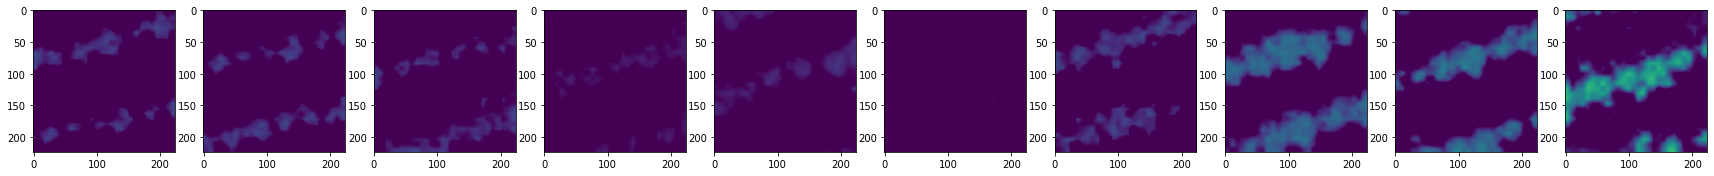

In [8]:
plt.figure(figsize=(30, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    q1, q99 = np.percentile(masks_explains[i+10][10], [1, 99])
    print(masks_explains[i+10][10].min(), masks_explains[i+10][10].max(), q1, q99)
    plt.imshow(masks_explains[i+10][10], vmin=0.2, vmax=0.5)

0.086168 0.266932 0.09549049999999999 0.25355724999999996
0.096523 0.267702 0.1083245 0.25404350000000003
0.109407 0.264079 0.11917675 0.248353
0.095642 0.227789 0.10415574999999999 0.219834
0.139785 0.245813 0.145488 0.23705800000000002
0.05627 0.209504 0.064801 0.19960775
0.073254 0.267988 0.08712475 0.25835225
0.128421 0.318839 0.14279750000000002 0.30804725
0.10919 0.32704 0.126588 0.31660825000000004
0.133536 0.40581 0.14859050000000001 0.38463025


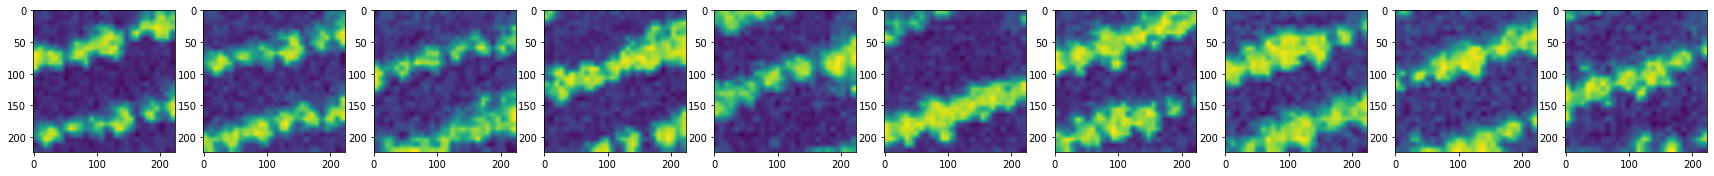

In [9]:
plt.figure(figsize=(30, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    q1, q99 = np.percentile(masks_explains[i+10][10], [1, 99])
    print(masks_explains[i+10][10].min(), masks_explains[i+10][10].max(), q1, q99)
    plt.imshow(masks_explains[i+10][10])

#### Shift for adjust tiles

In [10]:
def mad(x):
    #med = np.median(x)
    med = np.nanmedian(x) 
    return np.nanmedian(np.abs(x - med)) + 1e-6


def shift_tiles_to_global(tiles, k=1.25, apply_scale=False):
    # global stats
    all_vals = np.concatenate([t.ravel() for row in tiles for t in row if np.any(t)])
    #mu_g = np.median(all_vals)
    mu_g = np.nanmedian(all_vals) 
    sigma_g = mad(all_vals)
    print("all", mu_g, sigma_g)
    out = []
    for row in tiles:
        row_out = []
        for t in row:
            if not np.any(t):
                row_out.append(t)
                continue

            mu_t = np.median(t[t != 0])
            sigma_t = mad(t[t != 0])

            # --- shift only ---
            delta = np.clip(mu_g - mu_t, -k*sigma_g, k*sigma_g)
            t_shifted = t + delta

            # --- optional mild scale ---
            if apply_scale:
                scale = np.sqrt(sigma_g / (sigma_t + 1e-6))
                scale = np.clip(scale, 0.85, 1.2)
                t_shifted *= scale

            row_out.append(t_shifted)

        out.append(row_out)

    return out

In [11]:
masks_explains2 = shift_tiles_to_global(masks_explains, k=1.5)

all 0.155647 0.052286


#### Window (optional)

In [57]:
def edge_feather_window(h, w, overlap):
    win = np.ones((h, w), dtype=np.float32)

    ramp = np.linspace(0, 1, overlap)
    win[:overlap, :] *= ramp[:, None]
    win[-overlap:, :] *= ramp[::-1, None]
    win[:, :overlap] *= ramp[None, :]
    win[:, -overlap:] *= ramp[::-1][None, :]

    return win

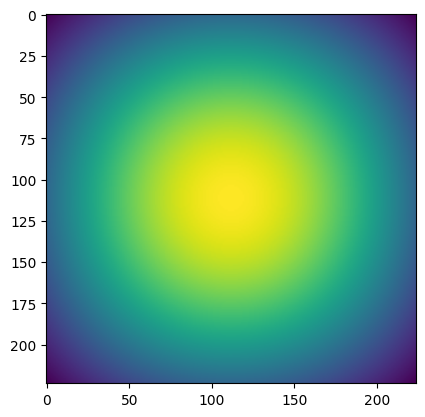

In [13]:
rows = []
overlap=112
tile_h, tile_w = masks_explains[0][0].shape#224x224

wy = np.hanning(tile_h*2)
wx = np.hanning(tile_w*2)
window = np.outer(wy, wx)
window = window / window.max()
window = window[112:336, 112:336]
#window = np.clip(window, 0, 1)

plt.imshow(window)

#### Merging tiles

In [12]:
print(len(masks_explains2), len(masks_explains2[0]))

107 71


In [13]:

overlap=112
tile_h, tile_w = masks_explains[0][0].shape#224x224
img_h = (len(masks_explains)+1) * (tile_h - overlap) #1*112
img_w = (len(masks_explains[0])+1) * (tile_w - overlap)#3*112

merged = np.zeros((img_h, img_w))
weight = np.zeros((img_h, img_w))

for i in range(len(masks_explains)-1):
    for j in range(len(masks_explains[0])-1):
        tile1 = masks_explains2[i][j]
        #print(tile1.min())

        merged[112*i:112*(i+2), 112*j:112*(j+2)] += tile1#*window#(tile1-tile1.min())/(tile1.max()-tile1.min()+1e-10)
        weight[112*i:112*(i+2), 112*j:112*(j+2)] += 1#window

merged = merged / (weight + 1e-10)
t1_q1, t1_q99 = np.nanpercentile(merged[merged!=0], [1, 99])
merged[merged!=0] = (merged[merged!=0]-t1_q1)/(t1_q99-t1_q1)
merged = np.clip(merged, 0, 1)


In [18]:
from PIL import Image
# Mode='L' explicitly indicates a grayscale image
img = Image.fromarray((255*merged).astype('uint8'), mode='L')

# 3. Save the image to a file
img.save("explainability_orthomap_"+zone_name+".png")
np.savez('data_explainability_orthomap_'+zone_name+'.npz', merged=merged)
#plt.imshow(merged)

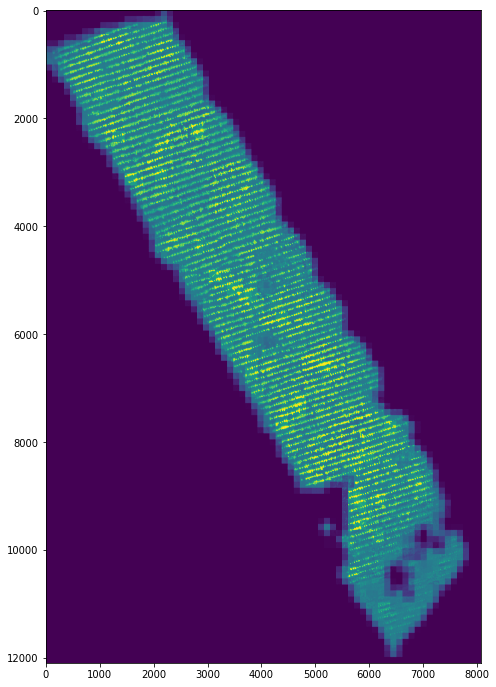

In [14]:
plt.figure(figsize=(12, 12))
plt.imshow(merged)

In [12]:
from PIL import Image
# Mode='L' explicitly indicates a grayscale image
img = Image.fromarray((255*merged).astype('uint8'), mode='L')

# 3. Save the image to a file
img.save("explainability_test3.png")

0.0 1.0
0.40115199220910225 1.0


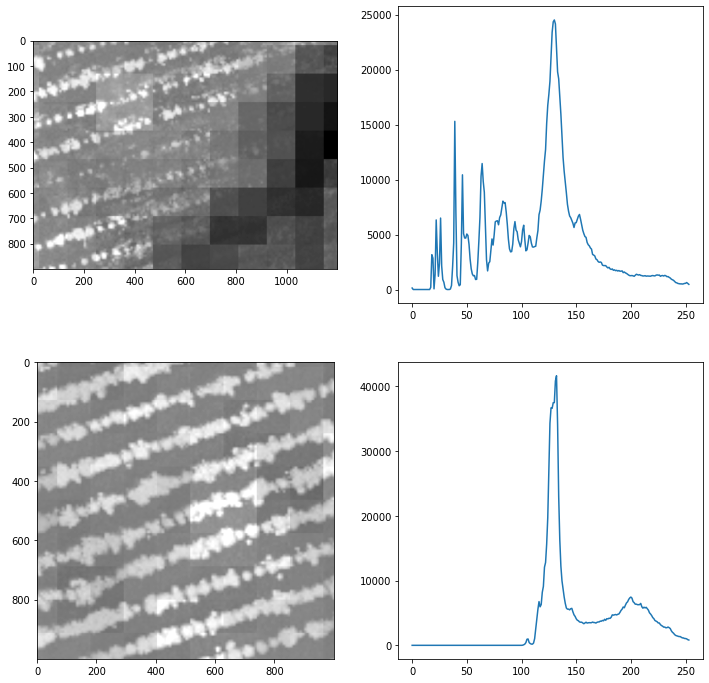

In [70]:
plt.figure(figsize=(12, 12))
im_test = merged[9500:10400, 5800:7000]
#im_test = merged[2000:3000, 1500:2500]
hist = cv2.calcHist([(255*im_test).astype('uint8')], [0], None, [256], [0, 256])
print(im_test.min(), im_test.max())
plt.subplot(2, 2, 1)
plt.imshow(im_test, cmap='gray', vmin=0, vmax=1)
#plt.imshow(merged[500:1500, 1000:2000])
plt.subplot(2, 2, 2)
plt.plot(hist[1:-1])

im_test = merged[2000:3000, 1500:2500]
hist = cv2.calcHist([(255*im_test).astype('uint8')], [0], None, [256], [0, 256])
print(im_test.min(), im_test.max())
plt.subplot(2, 2, 3)
plt.imshow(im_test, cmap='gray', vmin=0, vmax=1)
#plt.imshow(merged[500:1500, 1000:2000])
plt.subplot(2, 2, 4)
plt.plot(hist[1:-1])

### Heat map

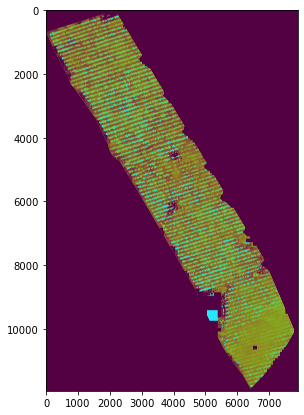

In [40]:
# Apply color map
plt.figure(figsize=(12, 7))
heatmap = cv2.applyColorMap((255*merged).astype(np.uint8), cv2.COLORMAP_VIRIDIS)
plt.imshow(heatmap)

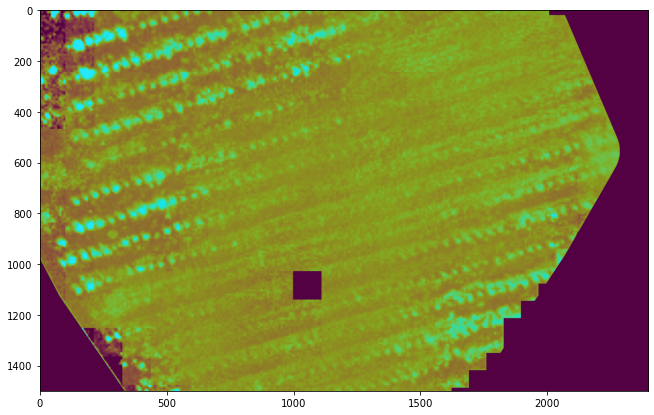

In [41]:
plt.figure(figsize=(12, 7))

plt.imshow(heatmap[9500:11000, 5500:8500, :])

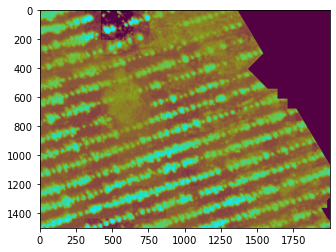

In [84]:
plt.imshow(heatmap[4500:6000, 3500:5500, :])

## Anomaly detection

In [111]:
# Para cargar los arrays desde el archivo
datos = np.load(folder_save_results+'data_boxes_'+zone_name+'.npz')
boxes_filtered = torch.tensor(datos['boxes_filtered'])
scores_filtered = torch.tensor(datos['scores_filtered'])
tokens_filtered = torch.tensor(datos['tokens_filtered'])
adjusts_filtered = torch.tensor(datos['adjusts_filtered'])

# To load the data later
with open(folder_save_results+'data_boxes_'+zone_name+'.pkl', 'rb') as f:
     masks_filtered = pickle.load(f)
del datos
print(zone_name)

Zone1


In [76]:
datos = np.load(folder_save_results+'data_explainability_orthomap_'+zone_name+'.npz')
merged = datos["merged"]
del datos

In [77]:
max(boxes_filtered[:,-1])

tensor(64.3574)

In [78]:
boxes_explains = []
for i, box_im in enumerate(boxes_filtered):
    box = np.array(box_im.cpu()).astype('int')

    xc, yc, r = box
    #print("yc+r", yc, r, yc+r)
    x1 = xc-r if xc-r>0 else 0
    x2 = xc+r if xc+r<merged.shape[1] else merged.shape[1]
    y1 = yc-r if yc-r>0 else 0
    y2 = yc+r if yc+r<merged.shape[0] else merged.shape[0]

    #box[0],box[2], box[1],box[3]
    box_im = merged[y1:y2,x1:x2]#, :]
    #print(box_im.shape)
    #box_im = box_im#(box_im.transpose(1, 2, 0)/box_im.max())

    #box_im = cv2.resize(box_im, (100, 100), interpolation = cv2.INTER_LINEAR)
    #if i==10:
    #    break
    boxes_explains.append(box_im)
#plt.imshow(box_im)

In [79]:
print(xc, yc, r)
print(x1, x2, y1, y2)
print(len(boxes_explains))

9253 6945 32
9221 9285 6913 6977
3496


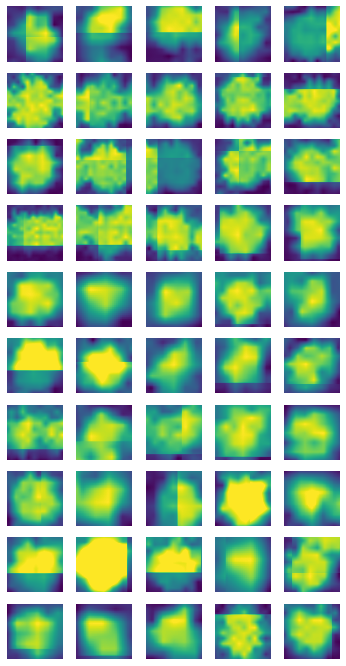

In [80]:
plt.figure(figsize=(6, 12))
for i in range(25):
    plt.subplot(10, 5, i+1)
    #plt.imshow(grays[i+2400,...])#, vmin=0, vmax=1)
    plt.imshow(boxes_explains[i+2400])#, vmin=0, vmax=1)
    plt.axis('off')
    
for i in range(25):
    plt.subplot(10, 5, i+25+1)
    #plt.imshow(grays[i+3400,...])#, vmin=0, vmax=1)
    plt.imshow(boxes_explains[i+3400])#, vmin=0, vmax=1)
    plt.axis('off')

Boxes resized...
Histograms computed...
 3495 
Anomalies: 42, with thr: 0.0055


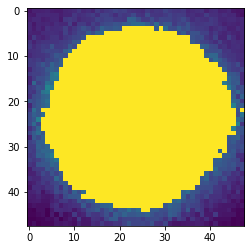

In [81]:
from model.explainability import anomaly_detection

scores, lower_bound, fingerprint = anomaly_detection(boxes_explains, bins=256, box_size=48)
#fingerprint #= (fingerprint-fingerprint.min())/(fingerprint.max()-fingerprint.min())
#fingerprint2 = (fingerprint-p1)/(p99-p1)
plt.imshow(fingerprint)

In [82]:
labels = np.where(scores<lower_bound, 0, 1)

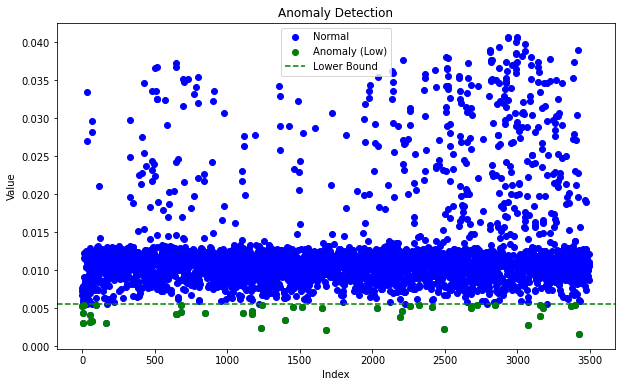

In [83]:
# Step 2: Define bounds
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR

# Step 3: Identify anomalies
#anomalies = data[(data < lower_bound) | (data > upper_bound)]
#print("Anomalies:", anomalies)  # Output: [100   1]

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(range(len(scores)), scores, color='blue', label='Normal')
#plt.scatter(np.where(data > upper_bound)[0], data[data > upper_bound], color='red', label='Anomaly (High)')
plt.scatter(np.where(scores < lower_bound)[0], scores[scores < lower_bound], color='green', label='Anomaly (Low)')
#plt.scatter(np.where(pvals_evt < 0.1)[0], data[(pvals_evt < 0.1)], color='green', label='Anomaly (Low)')
#plt.axhline(y=upper_bound, color='r', linestyle='--', label='Upper Bound')
plt.axhline(y=lower_bound, color='g', linestyle='--', label='Lower Bound')
plt.title("Anomaly Detection")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.show()

In [84]:
adnormal_array = scores
adnormal_array.min(),adnormal_array.max()

(0.0015913524186371728, 0.04065236262077295)

(array([  3.,   4.,   4.,  11.,  21.,  42.,  63., 136., 215., 354., 427.,
        546., 571., 474., 177.,  25.,  22.,  13.,  19.,  13.,   9.,  17.,
          7.,  21.,  10.,  18.,  12.,  18.,  12.,  11.,  10.,   6.,  18.,
         12.,  10.,  16.,  11.,  10.,  13.,  14.,  11.,  15.,  19.,  13.,
         12.,  10.,   8.,   6.,   2.,   5.]),
 array([0.00159135, 0.00237257, 0.00315379, 0.00393501, 0.00471623,
        0.00549745, 0.00627867, 0.00705989, 0.00784111, 0.00862233,
        0.00940355, 0.01018477, 0.01096599, 0.01174722, 0.01252844,
        0.01330966, 0.01409088, 0.0148721 , 0.01565332, 0.01643454,
        0.01721576, 0.01799698, 0.0187782 , 0.01955942, 0.02034064,
        0.02112186, 0.02190308, 0.0226843 , 0.02346552, 0.02424674,
        0.02502796, 0.02580918, 0.0265904 , 0.02737162, 0.02815284,
        0.02893406, 0.02971528, 0.0304965 , 0.03127772, 0.03205894,
        0.03284016, 0.03362138, 0.0344026 , 0.03518382, 0.03596504,
        0.03674626, 0.03752748, 0.0383087 , 0.

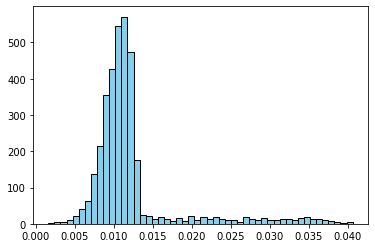

In [85]:
#hist = cv2.calcHist([(255*((adnormal_array-adnormal_array.min())/(adnormal_array.max()-adnormal_array.min()))).astype('uint8')], [0], None, [256], [0, 256])
plt.hist(adnormal_array, bins=50, color='skyblue', edgecolor='black')


## Clusters Visualizations

In [83]:
import numpy as np
import random

from matplotlib import pyplot as plt
import cv2

import time
import pandas as pd

root = '/home/a01328525/'
#root = 'E:/Experiments/'

folder_maps = root+'Datasets Maps/'
folder_tiles = root+'Datasets Tiles/'
folder_save_results = root+'Counting images paper 2/'
folder_trained_models = root+"Datasets_STED/runs_transformers/"

In [84]:
#zone_name = 'Zone3'

print("Reading "+folder_maps + zone_name + "_bgr_improved.png ...")
img = cv2.imread(folder_maps + zone_name + "_bgr.png")
img = img[...,[2, 1, 0]].copy()
print(zone_name)
img.shape

Reading /home/a01328525/Datasets Maps/Zone108_octubre_bgr_improved.png ...
Zone108_octubre


(5757, 7033, 3)

In [85]:
"""file_name = folder_maps + zone_name + "_labels.txt"
boxes_gt = torch.tensor([]).to(device)
classes_gt = torch.tensor([]).to(device)
with open(file_name, "r") as f:
    lines = f.readlines()
for line in lines:
    data = np.fromstring(line, sep=' ')
    
    cnt = data[5:]
    cnt = cnt.reshape(-1, 2)
    if obj == 'bbox':
        box_gt = torch.tensor(np.array([data[1:5]])).to(device)#x1y1x2y2
    else:
        (xc,yc),radius = cv2.minEnclosingCircle(cnt.astype('int'))
        box_gt = torch.tensor(np.array([[xc, yc, radius]])).to(device)
    #class_gt = torch.tensor(np.array([data[0]])).to(device)
    class_gt = torch.tensor(np.array([0])).to(device)#all 0 when onnly one class

    boxes_gt = torch.concat((boxes_gt, box_gt))
    classes_gt = torch.concat((classes_gt, class_gt))
print("Ground Truth read for %s with %d boxes"%(zone_name, boxes_gt.shape[0]))
boxes_filtered = boxes_gt"""

'file_name = folder_maps + zone_name + "_labels.txt"\nboxes_gt = torch.tensor([]).to(device)\nclasses_gt = torch.tensor([]).to(device)\nwith open(file_name, "r") as f:\n    lines = f.readlines()\nfor line in lines:\n    data = np.fromstring(line, sep=\' \')\n    \n    cnt = data[5:]\n    cnt = cnt.reshape(-1, 2)\n    if obj == \'bbox\':\n        box_gt = torch.tensor(np.array([data[1:5]])).to(device)#x1y1x2y2\n    else:\n        (xc,yc),radius = cv2.minEnclosingCircle(cnt.astype(\'int\'))\n        box_gt = torch.tensor(np.array([[xc, yc, radius]])).to(device)\n    #class_gt = torch.tensor(np.array([data[0]])).to(device)\n    class_gt = torch.tensor(np.array([0])).to(device)#all 0 when onnly one class\n\n    boxes_gt = torch.concat((boxes_gt, box_gt))\n    classes_gt = torch.concat((classes_gt, class_gt))\nprint("Ground Truth read for %s with %d boxes"%(zone_name, boxes_gt.shape[0]))\nboxes_filtered = boxes_gt'

In [53]:
boxes_filtered[12]

tensor([283.9208, 274.1305,  11.6438])

Text(0.5, 1.0, 'clusters')

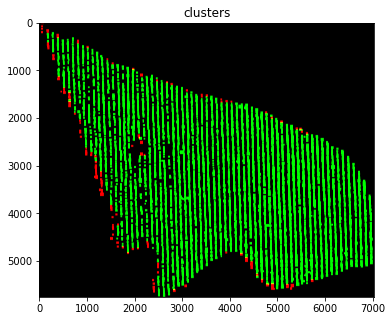

In [54]:
ind_1 = np.where(np.array(labels)==0)[0] #select the cluster with the minimum area average 
ind_2 = np.where(np.array(labels)==1)[0]
ind_3 = np.where(np.array(labels)==2)[0]

#ind_1 = np.where(np.array(df['Target'])==0)[0]
#ind_2 = np.where(np.array(df['Target'])==1)[0]
#ind_3 = np.where(np.array(df['Target'])==2)[0]

#cv2.rectangle(imgnp, (int(boxes_filtered[i][0]), int(boxes_filtered[i][1])), (int(boxes_filtered[i][2]), int(boxes_filtered[i][3])), (0, 255, 0), 2)
s = np.zeros_like(img)
#for i, box in enumerate(reversed(boxes_filtered)):
for i, box in enumerate(boxes_filtered):
    #if len(all_masks[i])==0:
    #    continue
    xc, yc, r = box
    
    #box_x1y1 = (int(boxes_filtered[i][0]), int(boxes_filtered[i][1]))
    #box_x2y2 = (int(boxes_filtered[i][2]), int(boxes_filtered[i][3]))
    
    #if i in ind_1:
    #    r = 5*r
        
    x1 = xc-r if xc-r>0 else 0
    x2 = xc+r if xc+r<img.shape[1] else img.shape[1]
    y1 = yc-r if yc-r>0 else 0
    y2 = yc+r if yc+r<img.shape[0] else img.shape[0]
    
    box_x1y1 = (int(x1), int(y1))
    box_x2y2 = (int(x2), int(y2))

    if i in ind_1:
        #cv2.drawContours(s, [masks_filter[i]], -1, (20, 255, 20), cv2.FILLED)
        cv2.rectangle(s, box_x1y1, box_x2y2, (255, 0, 0), cv2.FILLED)
    if i in ind_2 or i in ind_3:
        #cv2.drawContours(s, [masks_filter[i]], -1, (255, 20, 20), cv2.FILLED)
        cv2.rectangle(s, box_x1y1, box_x2y2, (0, 255, 0), cv2.FILLED)
    #if i in ind_3:
        #cv2.drawContours(s, [masks_filter[i]], -1, (20, 20, 255), cv2.FILLED)
    #    cv2.rectangle(s, box_x1y1, box_x2y2, (0, 25, 255), cv2.FILLED)

kernel = np.ones((5,5), np.uint8)
s = cv2.dilate(s, kernel, iterations=5)

plt.figure(figsize=(6, 6))
#plt.subplot(1, 3, t_+1)
plt.imshow(s)
plt.title('clusters')

In [55]:
len(ind_1), len(ind_2), len(ind_3), len(ind_1)+len(ind_2)+len(ind_3)

(148, 4763, 0, 4911)

150 5379 0


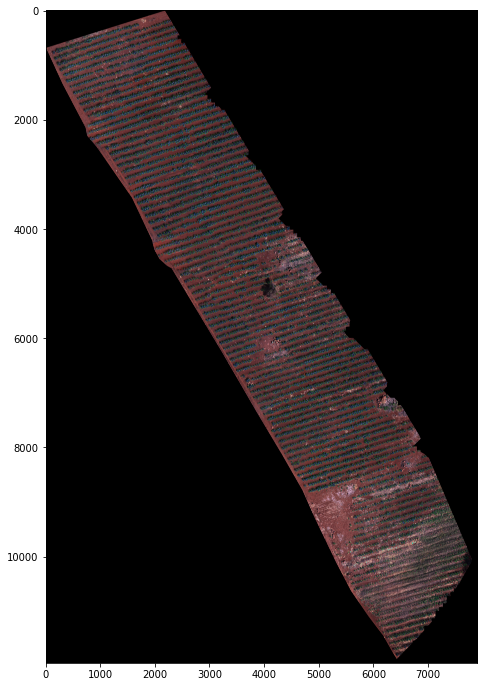

In [45]:
ind_1 = np.where(np.array(labels)==0)[0] #select the cluster with the minimum area average 
ind_2 = np.where(np.array(labels)==1)[0]
ind_3 = np.where(np.array(labels)==2)[0] #select the cluster with the maximum area average
counter_an = 0
counter_2 = 0
counter_3 = 0
#cv2.rectangle(imgnp, (int(boxes_filtered[i][0]), int(boxes_filtered[i][1])), (int(boxes_filtered[i][2]), int(boxes_filtered[i][3])), (0, 255, 0), 2)
#img = imgnp#np.zeros_like(imgnp)
#for i, box in enumerate(reversed(boxes_filtered)):
for i, box in enumerate(boxes_filtered):
    #if len(all_masks[i])==0:
    #    continue
    xc, yc, r = box
    #box_x1y1 = (int(boxes_filtered[i][0]), int(boxes_filtered[i][1]))
    #box_x2y2 = (int(boxes_filtered[i][2]), int(boxes_filtered[i][3]))
    
    x1 = xc-r if xc-r>0 else 0
    x2 = xc+r if xc+r<img.shape[1] else img.shape[1]
    y1 = yc-r if yc-r>0 else 0
    y2 = yc+r if yc+r<img.shape[0] else img.shape[0]
    
    box_x1y1 = (int(x1), int(y1))
    box_x2y2 = (int(x2), int(y2))
    if i in ind_1:
        #cv2.drawContours(s, [masks_filter[i]], -1, (20, 255, 20), cv2.FILLED)
        #cv2.rectangle(img, box_x1y1, box_x2y2, (255, 0, 0))
        counter_an +=1
        cv2.circle(img, center=(int(xc), int(yc)), radius=int(r), color=(255, 25, 0), thickness=1)
    if i in ind_2:
        counter_2+=1
        #cv2.drawContours(s, [masks_filter[i]], -1, (255, 20, 20), cv2.FILLED)
        #cv2.rectangle(img, box_x1y1, box_x2y2, (0, 255, 0))
        cv2.circle(img, center=(int(xc), int(yc)), radius=int(r), color=(25, 255, 0), thickness=1)
    if i in ind_3:
        counter_3+=1
        #cv2.drawContours(s, [masks_filter[i]], -1, (20, 20, 255), cv2.FILLED)
        #cv2.rectangle(img, box_x1y1, box_x2y2, (0, 205, 155))
        cv2.circle(img, center=(int(xc), int(yc)), radius=int(r), color=(0, 25, 255), thickness=1)

plt.figure(figsize=(12, 12))
#plt.subplot(1, 3, t_+1)
plt.imshow(img)
#plt.title('clusters')
#plt.savefig("anomaly2.png", dpi=300)
print(counter_an, counter_2, counter_3)

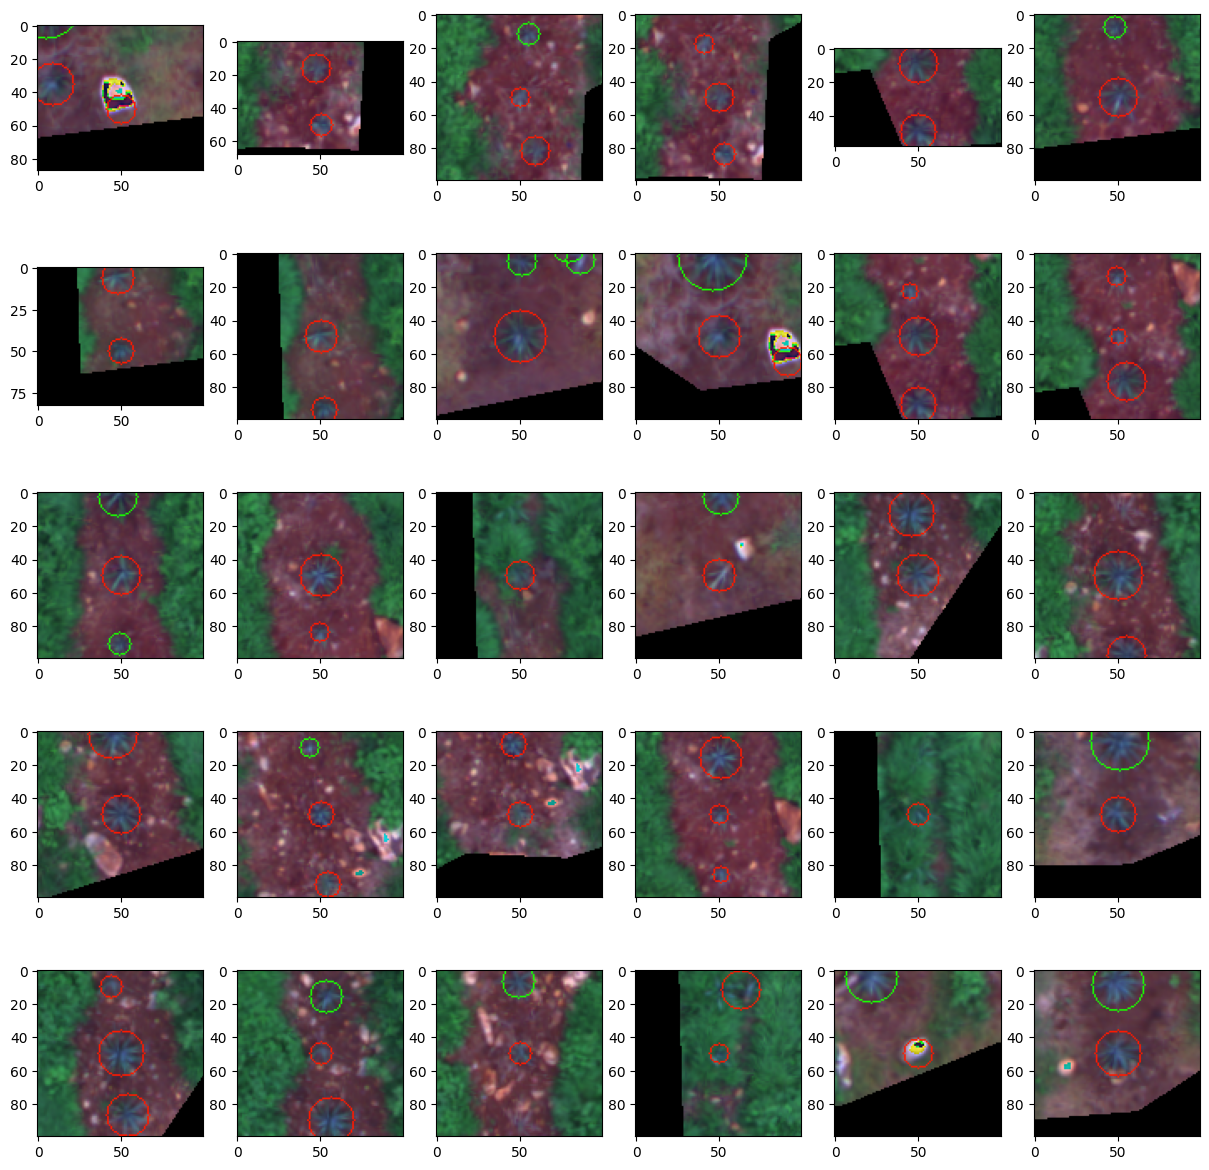

In [42]:
plt.figure(figsize=(15, 15))
l=1
for i in reversed(ind_1):
    xc, yc, r = boxes_filtered[i]
    r=25
    x1 = xc-r if xc-r>0 else 0
    x2 = xc+r if xc+r<img.shape[1] else img.shape[1]
    y1 = yc-r if yc-r>0 else 0
    y2 = yc+r if yc+r<img.shape[0] else img.shape[0]
    
    box_x1y1 = (int(x1), int(y1))
    box_x2y2 = (int(x2), int(y2))

    w = r#int(r*0.2)
    plt.subplot(5, 6, l)
    box_x1 = box_x1y1[1]-w if box_x1y1[1]-w>0 else 0
    box_x2 = box_x2y2[1]+w if box_x2y2[1]+w else img.shape[0]-1
    box_y1 = box_x1y1[0]-w if box_x1y1[0]-w>0 else 0
    box_y2 = box_x2y2[0]+w if box_x2y2[0]+w else img.shape[1]-1
    
    im_t = img[box_x1:box_x2, box_y1:box_y2]

    plt.imshow(im_t)
    #cv2.rectangle(imgnp, (int(boxes_filtered[i][0]), int(boxes_filtered[i][1])), (int(boxes_filtered[i][2]), int(boxes_filtered[i][3])), (255, 0, 0), 2)
    l+=1
    if l==31:
        break

In [3]:
for model_dir in models_dir:
    
    
    print(model_dir)
    #data, final_result = counting.get_counting_orthomap(folder_maps, zone_name, model_dir, imgnp, 
    #                                                    conf_thr, iou_thr, diou_thr, img_size, device, nms=False)
    n_model, num_blks, obj, N_channels, channels, loss_type, bitNet = counting.get_model_pars_from_dir(model_dir)
    
    #result = counting.get_boxes_map(model_dir, imgnp, N_channels, n_model, num_blks, loss_type, obj, 
    #                                       channels, conf_thr, iou_thr, diou_thr, img_size, device, bitNet, nms)
    ch = channels
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, loss_type= loss_type, device=device, bitNet=bitNet).to(device)
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
    print("Model loaded")
    
    n_pars = counting.count_parameters(model)
    n_size_mb = counting.model_size(model)
    
    B = imgnp[0,:,:]
    G = imgnp[1,:,:]
    R = imgnp[2,:,:]
    Re = imgnp[3,:,:]
    NIR = imgnp[4,:,:]
    
    #imgnp = imgnp.transpose((1, 2, 0)) # W x H x N channels
    #imgnp = imgnp[:,:,channels]
    
    if ch == 'bgr':
        img = cv2.merge((B, G, R))
    elif ch == 'multispectral':
        img = cv2.merge((B, G, R, Re, NIR))
    elif ch == 'vi':
        VI_N = ['NDCI', 'TSAVI2', 'ARVI']
        channels = (B, G, R, Re, NIR) 
        VI_1 = VI(channels, VI_N[0], ranges=None)
        VI_2 = VI(channels, VI_N[1], ranges=None)
        VI_3 = VI(channels, VI_N[2], ranges=None)
        img = cv2.merge((B, G, R, VI_1, VI_2, VI_3))       
    elif ch == 'viShadowAttenuation': #incomplete
        VI_1 = imgnp[5,:,:]
        VI_2 = imgnp[6,:,:]
        VI_3 = imgnp[7,:,:]
        img = cv2.merge((B, G, R, VI_1, VI_2, VI_3))
    else:
        print("Error loading map")  
    print("Map loaded: "+str(imgnp.shape) )
    
    all_boxes = torch.tensor([]).to(device)
    all_scores = torch.tensor([]).to(device)
    all_categories = torch.tensor([]).to(device)
    all_tokens = torch.tensor([]).to(device)
    all_adjusts = torch.tensor([]).to(device)
    times_predict = []
    
    for i in range(0, img.shape[0], img_size//2):
        for j in range(0, img.shape[1], img_size//2):
            i2 = i+img_size if i+img_size < img.shape[0] else img.shape[0]-1
            j2 = j+img_size if j+img_size < img.shape[1] else img.shape[1]-1

            im = np.zeros((img_size, img_size, img.shape[-1]))
            im[0:i2-i, 0:j2-j, :] = img[i:i2,j:j2, :]
            im = (torch.Tensor(im).permute(2, 0, 1).unsqueeze(0)).to(device) #1 x n channels x W x H
            
            start_b = time.time()        
            #boxes, scores  = counting.inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)            
            boxes, scores, tokens, adjusts  = inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(i, j), device=device)
            end_b = time.time()
            times_predict.append(end_b-start_b)
            boxes, scores = boxes[0], scores[0]
            print('\r', "Tile %4d:%4d, %4d:%4d, Objects Detected: %3d"%(i, i2, j, j2, len(boxes)), end='')
            
            if boxes!=None:
                all_boxes = torch.concat((all_boxes, boxes))
                all_scores = torch.concat((all_scores, scores))
                all_tokens = torch.concat((all_tokens, tokens))
                
    print()
    print("All boxes detected: %d"%(len(all_boxes)))
    #bboxes x1y1x2y2 and circles xc yc r
    index_filter_boxes = utils.utils.non_max_suppression_area(all_boxes, all_scores, iou_threshold=iou_thr, obj=obj, device=device)
        
    N_boxes = len(index_filter_boxes)
    print("Boxes filtered detected: %d"%(N_boxes))
    
    boxes_filtered = all_boxes[[index_filter_boxes]]
    scores_filtered = all_scores[[index_filter_boxes]]
    
    imgnp, all_boxes, all_scores, boxes_filtered, scores_filtered, n_pars, n_size_mb, time_avg_pred, obj = result
    
    ############ Object Detection Metrics ##############################
    file_name = folder_maps + zone_name + "_labels.txt"
    boxes_gt = torch.tensor([]).to(device)
    classes_gt = torch.tensor([]).to(device)
    with open(file_name, "r") as f:
        lines = f.readlines()
    for line in lines:
        data = np.fromstring(line, sep=' ')
        
        cnt = data[5:]
        cnt = cnt.reshape(-1, 2)
        if obj == 'bbox':
            box_gt = torch.tensor(np.array([data[1:5]])).to(device)#x1y1x2y2
        else:
            (xc,yc),radius = cv2.minEnclosingCircle(cnt.astype('int'))
            box_gt = torch.tensor(np.array([[xc, yc, radius]])).to(device)
        class_gt = torch.tensor(np.array([data[0]])).to(device)

        boxes_gt = torch.concat((boxes_gt, box_gt))
        classes_gt = torch.concat((classes_gt, class_gt))
    print("Ground Truth read for %s with %d boxes"%(zone_name, boxes_gt.shape[0]))
    
    #data = np.array([int(len(scores_filtered)), N_agaves_real, n_pars, np.round(n_size_mb, 3), np.round(time_avg_pred*1000, 2), np.round(mAP50, 2), int(N_agaves_mAP50), 
    #                 np.round(mAP75, 2), int(N_agaves_mAP75), np.round(mAP95, 2), int(N_agaves_mAP95),
    #                 np.round(d_recall, 2), np.round(d_precision, 2), np.round(d_f1, 2),
    #                 np.round(d_recall2, 2), np.round(d_precision2, 2), np.round(d_f12, 2),
    #                 np.round(d_recall3, 2), np.round(d_precision3, 2), np.round(d_f13, 2),
    #                 len(TP_index), len(FP_index), len(FN_index) ])
    
    dat.append(data)
    final_results.append(final_result)
    print(map_dir+' finished')

E:/Experiments/Datasets_STED/runs_transformers/STED_101_nano_cbbox_bgr_diou_BitNet/best.pt
Model loaded
Map loaded: (10, 5807, 7070)
 Tile 5712:5806, 7056:7069, Objects Detected:   0
All boxes detected: 20417


OutOfMemoryError: CUDA out of memory. Tried to allocate 382.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 6.56 GiB is allocated by PyTorch, and 319.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)